In [1]:
import sys
sys.path.append("../src")
from data_loader import load_prices

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

prices = load_prices()
print(prices.shape)
print(prices.isna().sum().sum())

(1509, 41)
0


In [2]:
# computing simple returns from scratch
simple_return = (prices - prices.shift(1)) / prices.shift(1)
simple_returns = simple_return.dropna()
print(simple_returns.shape)
print(simple_returns.head(3))

(1508, 41)
Ticker          AAPL       ABT      AMZN       AXP       BAC         C  \
Date                                                                     
2018-01-03 -0.000174  0.002211  0.012775  0.006165 -0.003345  0.003093   
2018-01-04  0.004645 -0.001697  0.004476  0.016633  0.013088  0.012334   
2018-01-05  0.011385  0.002890  0.016163  0.002281  0.004637 -0.001324   

Ticker           CAT        CL       COP      COST  ...       PFE        PG  \
Date                                                ...                       
2018-01-03  0.001528 -0.003859  0.018438  0.012001  ...  0.007410 -0.001214   
2018-01-04  0.013734  0.006413  0.011537 -0.007766  ...  0.002179  0.007069   
2018-01-05  0.015805  0.001195 -0.001930 -0.007139  ...  0.001903  0.000658   

Ticker          PYPL       SLB       TGT       UNH         V       WFC  \
Date                                                                     
2018-01-03  0.039410  0.026036 -0.006802  0.010490  0.009955  0.007694   


In [3]:
# computing log returns from scratch
log_returns = np.log(prices/prices.shift(1))
log_returns = log_returns.dropna()
print(log_returns.shape )

comparison = pd.DataFrame({
    "simple" : simple_returns["XOM"],
    "log" : log_returns["XOM"]
})

print(comparison.head(10))

(1508, 41)
              simple       log
Date                          
2018-01-03  0.019640  0.019450
2018-01-04  0.001384  0.001383
2018-01-05 -0.000806 -0.000806
2018-01-08  0.004496  0.004486
2018-01-09 -0.004246 -0.004255
2018-01-10 -0.007952 -0.007984
2018-01-11  0.009875  0.009826
2018-01-12  0.006787  0.006764
2018-01-16 -0.006284 -0.006304
2018-01-17  0.011843  0.011773


In [4]:
# verifying the additivity of log returns

# sum of daily log return for XOM in jan 2020
jan_log = log_returns["XOM"]["2020-01-02" : "2020-01-31"]
summed = jan_log.sum()

# direct calculation
start_price = prices["XOM"]["2019-12-31"]
end_price = prices["XOM"]["2020-01-31"]
direct = np.log(end_price/start_price)

print("Summed daily log returns:" , summed)
print("Direct log ratio:", direct)
print("Difference:" , abs(summed - direct))

Summed daily log returns: -0.11627922437159569
Direct log ratio: -0.11627922437159532
Difference: 3.608224830031759e-16


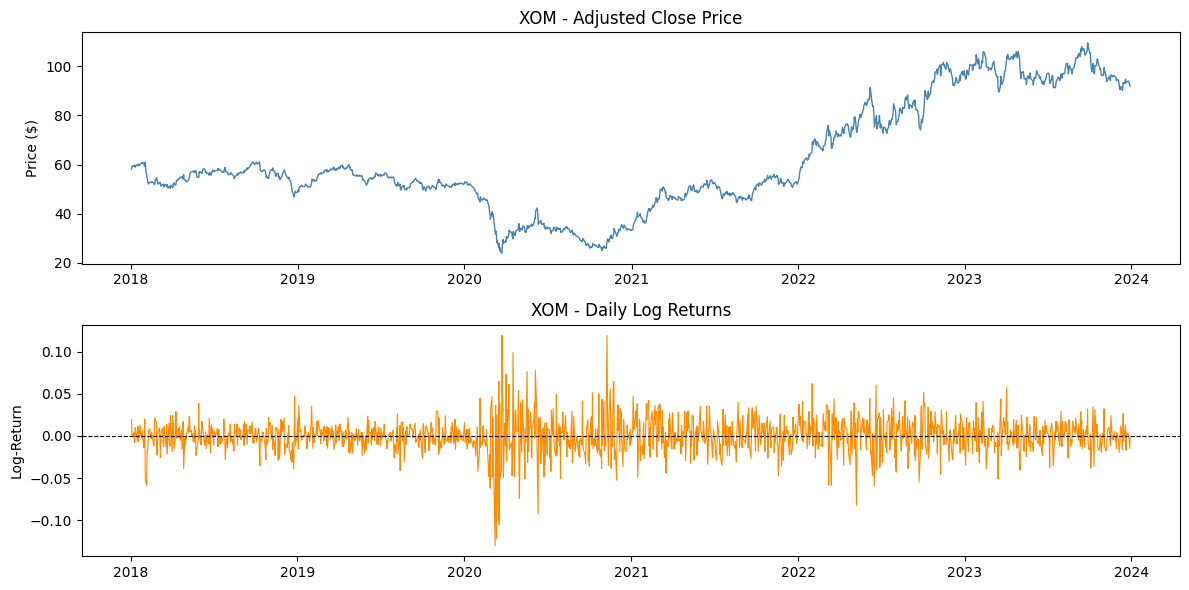

In [5]:
# plot price series vs return series for XOM
fig , axes = plt.subplots(2,1, figsize= (12,6))

# top plot - price
axes[0].plot(prices.index,prices["XOM"] , color = 'steelblue' , linewidth = 1)
axes[0].set_title("XOM - Adjusted Close Price")
axes[0].set_ylabel("Price ($)")

# bottom plot - log returns
axes[1].plot(log_returns.index,log_returns["XOM"], color = 'darkorange' , linewidth = 0.8)
axes[1].set_title("XOM - Daily Log Returns")
axes[1].set_ylabel("Log-Return")
axes[1].axhline(0,color = 'black' , linestyle = '--' , linewidth = 0.8)

plt.tight_layout()
plt.savefig("../data/price_vs_log_returns_XOM.png",dpi = 120)
plt.show()


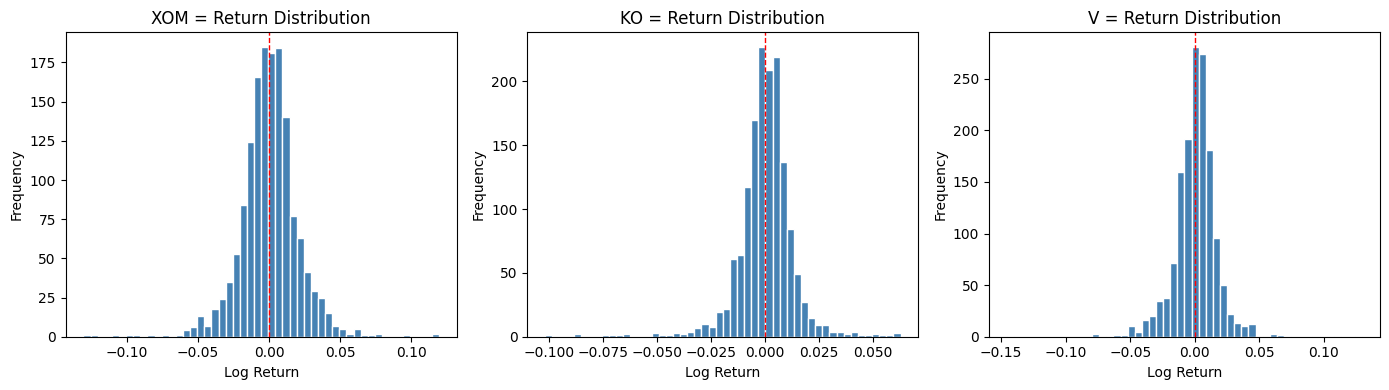

In [6]:
tickers_to_plot = ["XOM", "KO" , "V"]

fig,axes = plt.subplots(1,3,figsize=(14,4))

for i,ticker in enumerate(tickers_to_plot):
    axes[i].hist(log_returns[ticker] , bins = 50, color = 'steelblue' , edgecolor = 'white')
    axes[i].set_title(f"{ticker} = Return Distribution")
    axes[i].set_xlabel("Log Return")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(x= 0, color = 'red' , linestyle = '--' , linewidth = 1)
    
plt.tight_layout()
plt.savefig("../data/return_distribution.png",dpi = 120)
plt.show()

In [7]:
# save log returns and update module

log_returns.to_parquet("../data/log_returns.parquet")

verify = pd.read_parquet("../data/log_returns.parquet")
print(verify.shape) 
print(verify.isna().sum().sum())


(1508, 41)
0


In [8]:
from data_loader import load_returns

returns = load_returns()
print(returns.shape)

(1508, 41)
